# Cross-Subject VNS Decoding

For every session that has both Kilosort results and a derivative `_noArti.mat` file:
1. Extract per-train parameters directly from the `stim_DAQ` signal (amplitude level, pulse width)
2. Build 500 ms binned spike-count feature vectors from good units
3. Run linear SVM + LOO cross-validation for each decodable contrast:
   - **VNS vs baseline (sham)**
   - **Amplitude level** (if ≥ 2 levels with ≥ 3 trials each)
   - **Pulse width** (if ≥ 2 widths detected with ≥ 3 trials each)
4. Aggregate and plot accuracy across all sessions / subjects

> **Data setup**: this notebook expects a `kilosort_results/` and a `derivative/` directory as described in the repo `README.md`. Point the `KILOSORT_RESULTS_DIR` / `DERIVATIVE_DIR` environment variables at your own copies before running, or edit the defaults in the next cell.

In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, permutation_test_score
from sklearn.cluster import KMeans
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import os

# Root folders for Kilosort output and the derivative .mat files.
# Override via environment variables so this notebook is portable across machines;
# defaults below match this lab's server layout.
RESULTS_DIR  = Path(os.environ.get('KILOSORT_RESULTS_DIR', '/home/nuttidalab/files/kilosort_results'))
DERIV_DIR    = Path(os.environ.get('DERIVATIVE_DIR',       '/home/nuttidalab/files/derivative'))

SAMPLE_RATE  = 24414.0625  # Hz, DAQ sampling rate for spike times and the stim_DAQ channel
WIN_DUR      = 5.0    # s, duration of a VNS stimulation train (and of the matched baseline window)
BIN_SIZE     = 0.5    # s, width of each spike-count bin used as a decoding feature
# NOTE: there's no fixed baseline offset here — each train's Sham window is anchored at the
# midpoint of the gap since the *previous* train (computed per-session below), so it adapts to
# that session's actual VNS train spacing instead of assuming a fixed recovery time for all.
N_BINS       = int(WIN_DUR / BIN_SIZE)          # number of 500 ms bins spanning one VNS train
DECODE_BINS  = np.linspace(0, WIN_DUR, N_BINS + 1)  # bin edges, relative to train/baseline onset
MIN_TRIALS   = 3      # minimum trials required per class before a contrast is decoded at all
N_PERMS      = 500    # permutations per condition for the null (chance) distribution


**About the parameters above**: each VNS trial is compared against a baseline window of the same length (`WIN_DUR`), anchored at the midpoint of the gap since the previous train (see the main loop below) so it sits maximally far from stimulation on both sides, regardless of how tightly that session's trains happen to be spaced. Spike counts are binned every `BIN_SIZE` seconds and concatenated across units into one feature vector per trial. `MIN_TRIALS` guards against decoding a contrast (e.g. amplitude level) from too few examples, and `N_PERMS` controls how many label-shuffles are used to build the chance-accuracy null distribution for the permutation test.

## Helper functions

Four reusable pieces used by the main loop below:
- `binned_spike_counts` — turns spike times for a set of units into one flattened, binned firing-rate feature vector for a single trial.
- `svm_decode` — fits a linear SVM with leave-one-out cross-validation and a permutation test, returning the real accuracy plus the null distribution's mean/std and p-value.
- `extract_train_params` — parses the raw `stim_DAQ` trace to recover each VNS train's onset time, amplitude, and pulse width.
- `cluster_to_labels` — groups a continuous parameter (e.g. amplitude) into a small number of discrete levels via k-means, so it can be used as a decoding target.

In [2]:
def binned_spike_counts(t_start, spike_times, spike_clusters, unit_ids,
                        bins=DECODE_BINS, bin_size=BIN_SIZE):
    """Firing rate (Hz) per bin per unit, flattened into one feature vector for a trial
    starting at t_start."""
    t_rel = spike_times - t_start
    feats = []
    for uid in unit_ids:
        counts, _ = np.histogram(t_rel[spike_clusters == uid], bins=bins)
        feats.append(counts / bin_size)
    return np.concatenate(feats)


def svm_decode(X, y):
    """
    Linear SVM with LOO-CV + permutation test.
    Returns (accuracy, perm_mean, perm_std, p_value) or all-nan if too few trials.
    """
    if len(X) < 2 * MIN_TRIALS or len(np.unique(y)) < 2:
        return np.nan, np.nan, np.nan, np.nan
    clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1.0))
    loo = LeaveOneOut()
    score, perm_scores, pvalue = permutation_test_score(
        clf, X, y, cv=loo, n_permutations=N_PERMS,
        scoring='accuracy', random_state=42, n_jobs=1
    )
    return score, perm_scores.mean(), perm_scores.std(), pvalue


def extract_train_params(stim_daq, time_vec):
    """Detect VNS pulse trains in the raw stim_DAQ trace and return, per train, its onset
    time plus amplitude / pulse-width (used as decoding targets below)."""
    abs_sig = np.abs(stim_daq)
    abs_max = abs_sig.max()
    if abs_max == 0:
        return None
    thresh   = abs_max * 0.3
    binary   = (abs_sig > thresh).astype(int)
    pulse_on  = np.where(np.diff(binary) == 1)[0] + 1
    pulse_off = np.where(np.diff(binary) == -1)[0] + 1
    if len(pulse_on) < 5:
        return None
    m = min(len(pulse_on), len(pulse_off))
    pulse_on, pulse_off = pulse_on[:m], pulse_off[:m]
    pulse_t  = time_vec[pulse_on]
    gaps     = np.diff(pulse_t)
    ts_idx   = np.concatenate([[0], np.where(gaps > 0.5)[0] + 1])
    te_idx   = np.concatenate([np.where(gaps > 0.5)[0], [m - 1]])
    onset_times, raw_amps, pw_ms = [], [], []
    for ts, te in zip(ts_idx, te_idx):
        p_on = pulse_on[ts:te + 1]
        p_off = pulse_off[ts:te + 1]
        amp = np.mean([abs_sig[pi:po + 1].max() for pi, po in zip(p_on, p_off)])
        raw_amps.append(amp)
        pw = np.median(time_vec[p_off] - time_vec[p_on]) * 1000
        pw_ms.append(pw)
        onset_times.append(pulse_t[ts])
    raw_amps = np.array(raw_amps)
    return dict(onset_times=np.array(onset_times),
                norm_amps=raw_amps / raw_amps.max(),
                raw_amps=raw_amps,
                pw_ms=np.array(pw_ms))


def cluster_to_labels(values, tol=0.15):
    """Group a 1-D continuous parameter (amplitude, pulse width, ...) into a small number of
    discrete k-means levels, picking the smallest k whose within-cluster spread (relative to
    the value range) is below tol."""
    v = values.reshape(-1, 1)
    rng = values.max() - values.min()
    if rng < 1e-6:
        return np.zeros(len(values), dtype=int), np.array([values.mean()]), 1
    for k in range(1, 8):
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(v)
        if km.inertia_ ** 0.5 / rng < tol:
            break
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(v)
    order     = np.argsort(km.cluster_centers_.flatten())
    label_map = {old: new for new, old in enumerate(order)}
    labels    = np.array([label_map[l] for l in km.labels_])
    centers   = np.sort(km.cluster_centers_.flatten())
    return labels, centers, k

print("Helpers defined.")


Helpers defined.


## Run decoding across all sessions

For every `subject/stim` folder under `RESULTS_DIR` that has a matching `_noArti.mat` file in `DERIV_DIR`: load the good-unit spike trains (skipping sessions with fewer than 10 good units), recover VNS train onsets and parameters from the DAQ trace, build paired VNS/baseline feature vectors, and decode each contrast that has enough trials. Each train's Sham window is anchored at the midpoint of the gap since the previous train — the first train in a session is skipped (no preceding train to pair with), as is any train whose gap is too tight to fit a clean, non-overlapping `WIN_DUR`-long baseline window at that midpoint. Results for every session and contrast are appended to `records`, then collected into one `results` DataFrame.

In [3]:
records = []

for ks_session in sorted(RESULTS_DIR.glob('*/*/')):
    subject = ks_session.parts[-2]
    stim    = ks_session.parts[-1]
    mat_path   = DERIV_DIR / subject / f'{stim}_noArti.mat'
    label_file = ks_session / 'cluster_KSLabel.tsv'
    if not mat_path.exists() or not label_file.exists():
        continue

    labels   = pd.read_csv(label_file, sep='\t')
    good_ids = labels.loc[labels['KSLabel'] == 'good', 'cluster_id'].values
    if len(good_ids) < 10:   # exclude sessions with fewer than 10 good units
        continue

    spike_times_s  = np.load(ks_session / 'spike_times.npy') / SAMPLE_RATE
    spike_clusters = np.load(ks_session / 'spike_clusters.npy')

    try:
        with h5py.File(mat_path, 'r') as f:
            stim_daq = f['stim_DAQ/data'][()].flatten()
            time_vec = f['time'][()].flatten()
    except Exception:
        continue

    params = extract_train_params(stim_daq, time_vec)
    if params is None or len(params['onset_times']) < MIN_TRIALS:
        continue

    train_onsets = params['onset_times']

    X_vns, X_base, valid_onsets = [], [], []
    for i, onset in enumerate(train_onsets):
        if i == 0:
            continue   # no preceding train to anchor a matched baseline midpoint
        gap = onset - train_onsets[i - 1]
        if gap / 2 < WIN_DUR:
            continue   # trains too close together to fit a clean, non-overlapping baseline window
        base_start = train_onsets[i - 1] + gap / 2 - WIN_DUR / 2   # midpoint of the gap, centred
        if base_start < 0:
            continue
        X_vns.append( binned_spike_counts(onset,      spike_times_s, spike_clusters, good_ids))
        X_base.append(binned_spike_counts(base_start, spike_times_s, spike_clusters, good_ids))
        valid_onsets.append(onset)

    if len(X_vns) < MIN_TRIALS:
        continue

    X_vns        = np.array(X_vns)
    X_base       = np.array(X_base)
    valid_onsets = np.array(valid_onsets)
    X_vb = np.vstack([X_vns, X_base])
    y_vb = np.array([1] * len(X_vns) + [0] * len(X_base))

    valid_mask = np.isin(train_onsets, valid_onsets)
    norm_amps  = params['norm_amps'][valid_mask]
    pw_ms      = params['pw_ms'][valid_mask]

    base_rec = dict(subject=subject, stim=stim,
                    n_good_units=len(good_ids), n_vns_trains=len(X_vns))

    def add(decode, X, y, chance_k):
        acc, pm, ps, pv = svm_decode(X, y)
        records.append({**base_rec, 'decode': decode,
                        'accuracy': acc,
                        'perm_mean': pm, 'perm_std': ps, 'pvalue': pv,
                        'chance': 1 / chance_k, 'n_classes': chance_k})

    # VNS vs baseline
    add('VNS vs Sham', X_vb, y_vb, 2)

    # Amplitude
    amp_labels, _, n_amp = cluster_to_labels(norm_amps)
    if n_amp >= 2:
        counts = np.bincount(amp_labels)
        keep   = np.where(counts >= MIN_TRIALS)[0]
        if len(keep) >= 2:
            mask  = np.isin(amp_labels, keep)
            remap = {old: new for new, old in enumerate(keep)}
            y_amp = np.array([remap[l] for l in amp_labels[mask]])
            add('Amplitude', X_vns[mask], y_amp, len(keep))

    # Pulse width
    pw_labels, _, n_pw = cluster_to_labels(pw_ms)
    if n_pw >= 2:
        counts = np.bincount(pw_labels)
        keep   = np.where(counts >= MIN_TRIALS)[0]
        if len(keep) >= 2:
            mask  = np.isin(pw_labels, keep)
            remap = {old: new for new, old in enumerate(keep)}
            y_pw  = np.array([remap[l] for l in pw_labels[mask]])
            add('Pulse Width', X_vns[mask], y_pw, len(keep))


    vns_acc = next((r['accuracy'] for r in reversed(records)
                    if r['decode'] == 'VNS vs Sham'
                    and r['subject'] == subject and r['stim'] == stim), np.nan)
    print(f"{subject}/{stim}: good={len(good_ids)}, trains={len(X_vns)}, "
          f"amp_lvls={n_amp}, pw_lvls={n_pw}, VNS={vns_acc:.0%}")

results = pd.DataFrame(records)
print(f"\nTotal sessions: {results[['subject','stim']].drop_duplicates().shape[0]}")
print(f"Total records:  {len(results)}")


sub-20171120-NTS-1/stim11: good=20, trains=19, amp_lvls=4, pw_lvls=7, VNS=37%
sub-20171120-NTS-1/stim16: good=18, trains=19, amp_lvls=4, pw_lvls=7, VNS=55%
sub-20171120-NTS-1/stim19: good=22, trains=19, amp_lvls=4, pw_lvls=7, VNS=39%
sub-20171120-NTS-1/stim3: good=10, trains=19, amp_lvls=4, pw_lvls=7, VNS=34%
sub-20171206-NTS-2/stim11: good=16, trains=19, amp_lvls=4, pw_lvls=7, VNS=89%
sub-20171206-NTS-2/stim15: good=18, trains=19, amp_lvls=4, pw_lvls=7, VNS=92%
sub-20171206-NTS-2/stim17: good=37, trains=19, amp_lvls=4, pw_lvls=7, VNS=100%
sub-20171206-NTS-2/stim3: good=14, trains=19, amp_lvls=4, pw_lvls=7, VNS=97%
sub-20171206-NTS-2/stim7: good=14, trains=19, amp_lvls=4, pw_lvls=7, VNS=100%
sub-20171212-NTS-3/stim2: good=14, trains=20, amp_lvls=4, pw_lvls=7, VNS=52%
sub-20171212-NTS-3/stim5: good=10, trains=20, amp_lvls=4, pw_lvls=7, VNS=75%
sub-20171212-NTS-3/stim7: good=17, trains=21, amp_lvls=5, pw_lvls=7, VNS=100%
sub-20171220-NTS-5/stim3: good=31, trains=21, amp_lvls=4, pw_lvls=7

## Box plot summary with significance

For each contrast (VNS vs Sham, Pulse Width, Amplitude), one panel shows real vs shuffled LOO accuracy per subject, box-plotted across that subject's sessions. Individual session dots are filled when that session's permutation p-value is below 0.05; the bracket above each subject reports a paired t-test of real vs shuffled accuracy across its sessions.

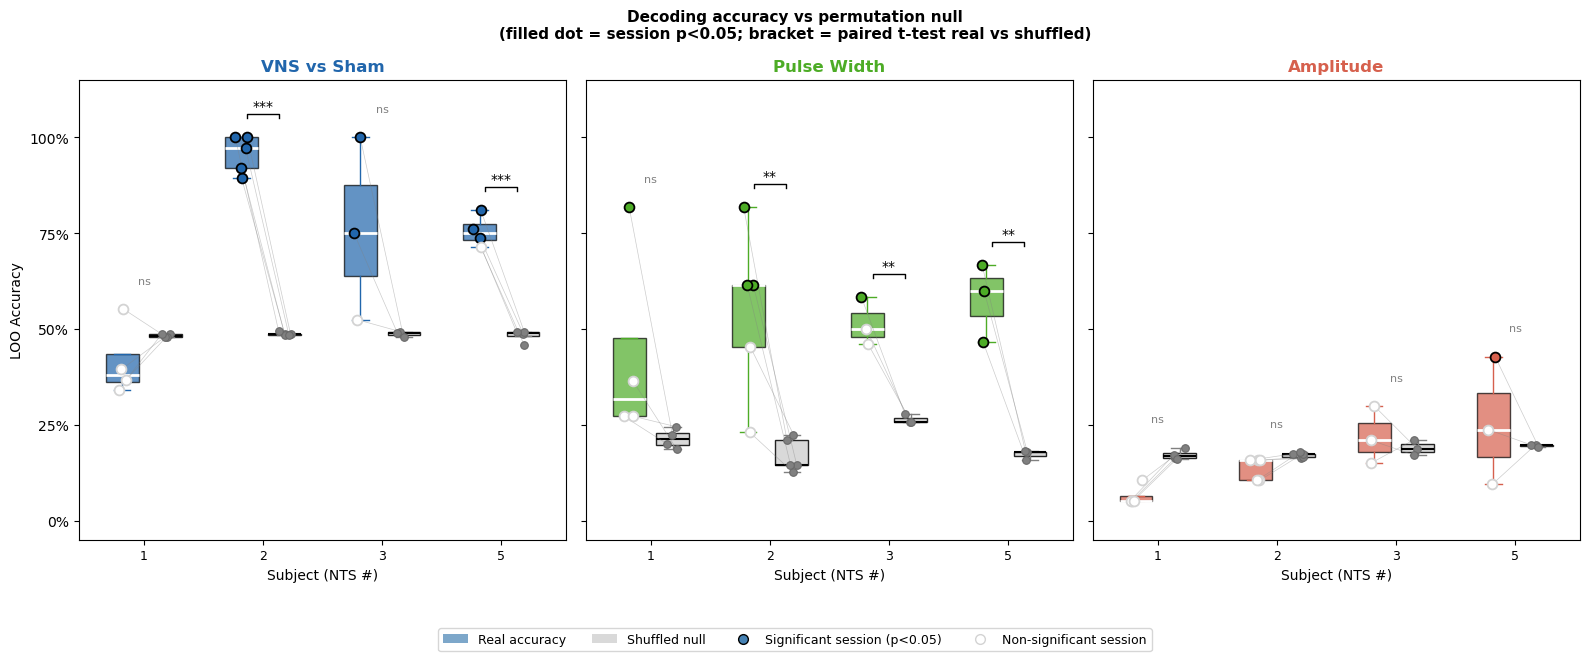

In [4]:
decode_types = ['VNS vs Sham', 'Pulse Width', 'Amplitude']
type_colors  = {'VNS vs Sham': '#2166ac', 'Pulse Width': '#4dac26', 'Amplitude': '#d6604d'}

subjects   = sorted(results['subject'].unique())
sub_labels = [s.split('-NTS-')[1] for s in subjects]

fig, axes = plt.subplots(1, len(decode_types), figsize=(16, 6), sharey=True)
fig.suptitle(
    'Decoding accuracy vs permutation null\n'
    '(filled dot = session p<0.05; bracket = paired t-test real vs shuffled)',
    fontsize=11, fontweight='bold'
)

for ax, dtype in zip(axes, decode_types):
    col = type_colors[dtype]
    df  = results[results['decode'] == dtype].dropna(subset=['accuracy','perm_mean']).copy()

    ax.set_title(dtype, fontweight='bold', color=col, fontsize=12)
    ax.set_ylim(-0.05, 1.15)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])

    pos_real, pos_shuf, dat_real, dat_shuf, xticks, brackets = [], [], [], [], [], []

    for i_sub, sub in enumerate(subjects):
        sub_df = df[df['subject'] == sub]
        if sub_df.empty:
            continue
        real = sub_df['accuracy'].values
        shuf = sub_df['perm_mean'].values
        x_r  = i_sub * 2.2
        x_s  = x_r + 0.8
        pos_real.append(x_r); pos_shuf.append(x_s)
        dat_real.append(real); dat_shuf.append(shuf)
        xticks.append((x_r + x_s) / 2)

        if len(real) >= 3:
            _, pv = stats.ttest_rel(real, shuf, alternative='greater')
        elif len(real) == 2:
            pv = 0.25 if (real > shuf).all() else 1.0
        else:
            pv = 1.0
        star = ('***' if pv < 0.001 else '**' if pv < 0.01
                else '*' if pv < 0.05 else 'ns')
        y_top = max(real.max(), shuf.max()) + 0.05
        brackets.append((x_r + 0.1, x_s - 0.1, y_top, star))

    if not dat_real:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        continue

    # boxes
    ax.boxplot(dat_real, positions=pos_real, widths=0.6, patch_artist=True,
               showfliers=False,
               medianprops=dict(color='white', linewidth=2),
               boxprops=dict(facecolor=col, alpha=0.7),
               whiskerprops=dict(color=col), capprops=dict(color=col))
    ax.boxplot(dat_shuf, positions=pos_shuf, widths=0.6, patch_artist=True,
               showfliers=False,
               medianprops=dict(color='k', linewidth=1.5),
               boxprops=dict(facecolor='lightgray', alpha=0.85),
               whiskerprops=dict(color='gray'), capprops=dict(color='gray'))

    # session dots + connecting lines
    for x_r, x_s, rv, sv, (_, sub) in zip(
            pos_real, pos_shuf, dat_real, dat_shuf,
            [(i, s) for i, s in enumerate(subjects)
             if not df[df['subject'] == s].empty]):
        sub_df   = df[df['subject'] == sub]
        pvals_s  = sub_df['pvalue'].values
        jit = np.random.uniform(-0.12, 0.12, len(rv))
        for j, (r, s, pv) in enumerate(zip(rv, sv, pvals_s)):
            ec = 'k' if (not np.isnan(pv) and pv < 0.05) else 'lightgray'
            fc = col if (not np.isnan(pv) and pv < 0.05) else 'white'
            ax.scatter(x_r + jit[j], r, s=50, color=fc,
                       edgecolors=ec, linewidths=1.3, zorder=5)
            ax.scatter(x_s + jit[j], s, s=30, color='gray',
                       edgecolors='dimgray', linewidths=0.8, zorder=5)
            ax.plot([x_r + jit[j], x_s + jit[j]], [r, s],
                    color='gray', lw=0.5, alpha=0.4, zorder=3)

    # significance brackets
    for xl, xr, yt, star in brackets:
        if star == 'ns':
            ax.text((xl + xr) / 2, yt + 0.01, 'ns',
                    ha='center', va='bottom', fontsize=8, color='gray')
        else:
            ax.plot([xl, xl, xr, xr], [yt, yt + 0.01, yt + 0.01, yt],
                    color='k', lw=1)
            ax.text((xl + xr) / 2, yt + 0.012, star,
                    ha='center', va='bottom', fontsize=10)

    ax.set_xticks(xticks)
    ax.set_xticklabels(sub_labels[:len(xticks)], fontsize=9)
    ax.set_xlabel('Subject (NTS #)')
    ax.set_xlim(-0.8, max(pos_shuf) + 0.8)

axes[0].set_ylabel('LOO Accuracy')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
leg = [
    Patch(facecolor='steelblue', alpha=0.7,   label='Real accuracy'),
    Patch(facecolor='lightgray', alpha=0.85,  label='Shuffled null'),
    Line2D([0],[0], marker='o', lw=0, markerfacecolor='steelblue',
           markeredgecolor='k', ms=7,    label='Significant session (p<0.05)'),
    Line2D([0],[0], marker='o', lw=0, markerfacecolor='white',
           markeredgecolor='lightgray', ms=7, label='Non-significant session'),
]
fig.legend(handles=leg, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.1), fontsize=9)
plt.tight_layout()
plt.savefig('vns_cross_subject_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


## Statistical summary (paired t-test: real vs shuffled)

Collapses the box plot into a table: for each subject and contrast, the mean real and shuffled accuracy, their difference, and a paired t-test p-value (real vs shuffled across that subject's sessions). With only 2 sessions a t-test isn't well-defined, so a simple sign-based fallback is used instead; with 1 session no p-value is reported.

In [5]:
rows = []
for dtype in ['VNS vs Sham', 'Pulse Width', 'Amplitude']:
    for sub in sorted(results['subject'].unique()):
        sub_df = results[(results['decode'] == dtype) &
                         (results['subject'] == sub)].dropna(subset=['accuracy','perm_mean'])
        if sub_df.empty:
            continue
        real = sub_df['accuracy'].values
        shuf = sub_df['perm_mean'].values
        n = len(real)
        if n >= 3:
            _, pv = stats.ttest_rel(real, shuf, alternative='greater')
        elif n == 2:
            pv = 0.25 if (real > shuf).all() else 1.0
        else:
            pv = np.nan
        rows.append(dict(
            Decode=dtype, Subject=sub.split('-NTS-')[1],
            N=n,
            Real_mean=round(real.mean(), 3),
            Shuf_mean=round(shuf.mean(), 3),
            Delta=round((real - shuf).mean(), 3),
            p_value=round(pv, 4) if not np.isnan(pv) else np.nan,
            Sig=('***' if (not np.isnan(pv) and pv<0.001) else
                 '**'  if (not np.isnan(pv) and pv<0.01)  else
                 '*'   if (not np.isnan(pv) and pv<0.05)  else 'ns')
        ))

stat_table = pd.DataFrame(rows)
print(stat_table.to_string(index=False))


     Decode Subject  N  Real_mean  Shuf_mean  Delta  p_value Sig
VNS vs Sham       1  4      0.414      0.483 -0.069   0.8719  ns
VNS vs Sham       2  5      0.958      0.488  0.470   0.0000 ***
VNS vs Sham       3  3      0.758      0.488  0.271   0.0979  ns
VNS vs Sham       5  4      0.756      0.483  0.273   0.0002 ***
Pulse Width       1  4      0.432      0.214  0.217   0.0956  ns
Pulse Width       2  5      0.547      0.171  0.376   0.0073  **
Pulse Width       3  3      0.515      0.265  0.250   0.0066  **
Pulse Width       5  3      0.578      0.173  0.405   0.0080  **
  Amplitude       1  4      0.066      0.172 -0.106   0.9996  ns
  Amplitude       2  5      0.137      0.172 -0.035   0.9575  ns
  Amplitude       3  3      0.220      0.190  0.030   0.3053  ns
  Amplitude       5  3      0.254      0.197  0.057   0.3083  ns


## Per-session detail

Full per-session accuracy table (rows = session, columns = contrast) for drilling into any individual result behind the summary plot/table above.

In [6]:
pivot = results.pivot_table(index=['subject','stim','n_good_units','n_vns_trains'],
                            columns='decode', values='accuracy').round(3)
print(pivot.to_string())

decode                                               Amplitude  Pulse Width  VNS vs Sham
subject            stim   n_good_units n_vns_trains                                     
sub-20171120-NTS-1 stim11 20           19                0.053        0.364        0.368
                   stim16 18           19                0.053        0.818        0.553
                   stim19 22           19                0.053        0.273        0.395
                   stim3  10           19                0.105        0.273        0.342
sub-20171206-NTS-2 stim11 16           19                0.158        0.818        0.895
                   stim15 18           19                0.158        0.231        0.921
                   stim17 37           19                0.158        0.615        1.000
                   stim3  14           19                0.105        0.455        0.974
                   stim7  14           19                0.105        0.615        1.000
sub-20171212-NTS-3 st